# Can Large Language Models Truly Do the Work of a Linguist?

### Naoko Ferreira-Redier, May 2026

# 1. Question

Large Language Models (LLMs) have achieved impressive performance across a wide range of natural language processing tasks, including translation, text generation, summarization, and question answering. However, these successes are not distributed equally across languages. Recent work has shown that language models tend to perform substantially better on high-resource languages than on morphologically rich or underrepresented languages (Lu et al., 2024). This limitation raises an important question: do LLMs truly learn linguistic structure, or do they primarily rely on statistical regularities found in their training data?

This question is particularly relevant for morphology. In some languages, grammatical information is expressed through separate words, while in others a single word may encode tense, person, number, location, and other grammatical categories simultaneously. Several recent studies suggest that current language models still struggle with this type of linguistic complexity, especially when dealing with low-resource languages or rare morphological constructions (Weissweiler et al., 2024; Asgari et al., 2025).

More broadly, this problem connects to a longstanding debate in linguistics. In generative approaches associated with Chomsky (1965), language is understood as an abstract system of rules and representations that cannot be reduced to surface statistics alone. More recently, Piantadosi (2024) argued that the remarkable performance of modern language models challenges this view and suggests that statistical learning may be sufficient to recover many aspects of linguistic structure. Determining which aspects of language can be inferred from distributional information alone remains an open question.

Human linguists do not simply memorize forms. When confronted with an unfamiliar language, they identify recurring patterns, formulate hypotheses about grammatical rules, compare alternative explanations, and test these hypotheses on new examples. The question is therefore whether a language model can perform a similar type of linguistic reasoning when faced with a completely unknown language.

To investigate this question, I created five artificial languages representing major morphological types found across the world's languages: isolating, analytic, fusional, agglutinative, and polysynthetic. Because all lexical items are invented, the model cannot rely on memorized linguistic knowledge and must instead infer grammatical structure directly from the examples it observes.

I ten tested the model Qwen 2.5 comparing two experimental conditions. In the first condition, the model only receives examples from the artificial language. In the second condition, the same examples are accompanied by English translations. This design allows me to evaluate whether access to semantic information improves the model's ability to discover grammatical structure.

The central research question is therefore:

**Can a large language model infer the morphological structure of unknown artificial languages, and does access to English translations improve its performance?**

### Hypotheses

**H1.** The model will successfully identify recurring morphological markers.

**H2.** English translations will improve the inference of grammatical functions.

**H3.** Typological classification and feature identification will be more difficult than local marker detection.

**H4.** Morphologically complex systems, particularly fusional and polysynthetic languages, will be harder to analyze than isolating and analytic systems.

**H5.** English translations will improve semantic interpretation and function identification more than they improve broader typological reasoning.

# 2. Data

The complete construction procedure is available in the notebook:

`language_generation/Languages_Construction.ipynb`

This notebook contains the code used to generate the artificial-language datasets.

## 2.1 Artificial languages

The data used in this project were created by me. I constructed five artificial languages specifically for this experiment. The goal was to create a controlled setting in which the vocabulary remains mostly constant, but the grammatical organization changes from one language to another.

All five languages share the same basic lexical roots. For example, the subject pronouns are based on forms such as `ma`, `ta`, and `lo`, and the lexical roots include verbs such as `daka` (“go”), `notu` (“eat”), `luma` (“see”), and `naku` (“cry”), as well as nouns such as `kano` (“city”), `toto` (“house”), `peli` (“food”), and `sotu` (“water”). This shared lexicon makes it possible to compare the model’s performance across languages while keeping the vocabulary stable. What changes across the five languages is how grammatical information is encoded.

The five languages were designed to represent five different morphological profiles: isolating, analytic, fusional, agglutinative, and polysynthetic. The model was not told these systems in the prompt. These rules were used only to construct the datasets and later to score the model’s answers.

| Language   | Intended type | Main grammatical strategy                                                               |
| ---------- | ------------- | --------------------------------------------------------------------------------------- |
| Language A | Isolating     | Grammatical meanings are expressed through independent particles.                       |
| Language B | Analytic      | Tense and grammatical relations are expressed through auxiliary-like or function words. |
| Language C | Fusional      | Person and tense are fused into prefixes.                                               |
| Language D | Agglutinative | Each suffix corresponds to a transparent grammatical function.                          |
| Language E | Polysynthetic | Subjects, locations and tense can be compressed into a complex predicate.               |

### Language A: isolating system

Language A was designed as an isolating language. In this system, grammatical information is expressed through separate words rather than through prefixes or suffixes. The lexical roots do not change form.

For example, tense is expressed through independent particles:

* `vek` marks future;
* `tun` marks past.

Plurality and location are also expressed through separate particles:

* `nul` marks plural;
* `du` marks motion toward a place;
* `ri` marks motion into a place;
* `na` marks location inside or at a place.

For example, a sentence meaning “I will go tomorrow” can be built with separate elements corresponding to time, subject, tense and verb:

```text
fila ma vek daka
```

Here, each element remains independent:

* `fila` = tomorrow;
* `ma` = I;
* `vek` = future;
* `daka` = go.

The important point is that the grammatical information is not attached to the verb. The form `daka` remains stable, and the future meaning is carried by the separate particle `vek`. This makes Language A maximally transparent and close to an isolating system.

### Language B: analytic system

Language B was designed as an analytic language. Like Language A, it mainly uses separate words rather than bound morphology. However, the grammatical organization is closer to an auxiliary/function-word system.

In this language:

* `zo` marks future;
* `ki` marks past;
* `enu` marks plural;
* `mu` marks motion toward a place;
* `nel` marks motion into a place;
* `sha` marks location inside or at a place.

For example, “I will go tomorrow” can be expressed as:

```text
ma zo daka fila
```

Here:

* `ma` = I;
* `zo` = future auxiliary-like marker;
* `daka` = go;
* `fila` = tomorrow.

The difference between Language A and Language B is subtle but important. Both languages use mostly separate forms, but Language B was designed to look more like an analytic system with auxiliary-like markers and more stable syntactic positions. Grammatical meanings are still expressed by independent forms, but these forms behave more like function words than loose particles.

### Language C: fusional prefixing system

Language C was designed as a fusional language. In this system, person and tense are not expressed by separate words. Instead, they are fused into prefixes attached to the verb.

The prefixes are organized by tense and person. For example:

* present prefixes: `me`, `ti`, `na`;
* past prefixes: `uk`, `ot`, `ev`;
* future prefixes: `ar`, `el`, `or`.

The important idea is that a single prefix can encode more than one grammatical category at the same time. For example, a form such as:

```text
ardaka
```

can be analyzed as:

* `ar` = future + first person;
* `daka` = go.

Similarly:

```text
ukdaka
```

can be analyzed as:

* `uk` = past + first person;
* `daka` = go.

This makes the system more difficult than Languages A and B because the model cannot simply map one visible word to one grammatical function. Instead, it must infer that a compact prefix may express both tense and person at once. This is the core fusional property of Language C.

Language C also includes other grammatical material, such as plural class markers and separate location markers:

* `dra` = motion toward;
* `vren` = motion into;
* `nim` = location in/at.

However, the central design principle of Language C is the fusion of person and tense inside prefixes.

### Language D: agglutinative suffixing system

Language D was designed as an agglutinative language. In this system, grammatical information is added after the lexical root through suffixes. Each suffix has a relatively stable function, and several suffixes can be chained together.

The main suffixes include:

* `ra` = future;
* `si` = past;
* `ka` = first person;
* `tu` = second person;
* `li` = third person;
* `min` = plural;
* `mu` = motion toward;
* `nun` = motion into;
* `ne` = location in/at.

For example, a form like:

```text
dakaraka
```

can be understood as a sequence of smaller parts:

* `daka` = go;
* `ra` = future;
* `ka` = first person.

The structure is therefore more morphological than in Languages A and B, because grammatical information is attached to the root. However, unlike Language C, the morphemes are not fused. Each suffix contributes a relatively clear and separate meaning. This is what makes Language D agglutinative: one morpheme generally corresponds to one grammatical function.

### Language E: polysynthetic-style system

Language E was designed as a polysynthetic-style system. It is the most compact of the five languages. Several grammatical meanings can be compressed into one complex predicate.

The language uses subject prefixes such as:

* `ma` = first person;
* `ta` = second person;
* `lo` = third person.

It also includes tense and location markers inside the complex predicate:

* `ru` = future;
* `se` = past;
* `mo` = motion toward;
* `nu` = motion into;
* `ni` = location in/at;
* `it` = plural.

For example, a form such as:

```text
madakarumo
```

can be interpreted as a complex predicate containing:

* `ma` = first person subject;
* `daka` = go;
* `ru` = future;
* `mo` = motion toward.

The aim of this language is not to fully reproduce all properties of natural polysynthetic languages, but to create a controlled artificial system in which several grammatical categories are integrated into a single complex form. This makes the model’s task harder because it must segment and interpret a dense form rather than relying on separate words.

### Why this design is useful

This design makes the experiment controlled. Since the five languages share a common lexicon, differences in model performance should mainly reflect differences in morphological organization rather than differences in vocabulary. The same meanings can be expressed through five different grammatical systems: separate particles, auxiliary-like words, fused prefixes, suffix chains, or complex predicates.

This allows the project to test whether Qwen 2.5 can do more than identify repeated strings. The model must infer whether grammatical information is expressed as free words, prefixes, suffixes, fused forms, or complex predicate structures. The ground truth contains this information, but it is not given to the model during prompting. It is only used afterward to evaluate the model’s outputs.


## 2.2 Experimental conditions

The same artificial languages were tested in two conditions:

1. **Without English translations:** the model only saw the artificial-language forms.
2. **With English translations:** the model saw the artificial-language forms paired with English meanings.

The model was asked to perform three tasks for each artificial language.

1. First, it completed a rule inference task. In this task, Qwen 2.5 had to inspect the examples and identify recurring units or morphemes. It also had to propose possible grammatical functions for these units, such as tense, person, plurality, location, predication, or clause-linking. This task tested whether the model could detect repeated formal patterns and connect them to possible grammatical roles.

2. Second, it completed a typological classification task. In this task, Qwen 2.5 had to classify each language as one of five morphological types: isolating, analytic, fusional, agglutinative, or polysynthetic. This task was more abstract than simple marker detection because the model had to infer the broader organization of the language. For example, it had to decide whether grammatical information appeared as separate words, prefixes, suffixes, fused markers, or complex predicates.

3. Third, it completed a generation task. In this task, Qwen 2.5 had to generate new plausible forms in the artificial language by reusing only the patterns visible in the dataset. This task tested whether the model could generalize beyond the examples it had seen, rather than simply listing repeated forms.

These three tasks were designed to approximate different parts of the work of a field linguist: observing recurring forms, forming hypotheses about their functions, identifying the type of grammatical system, and testing those hypotheses by applying them to new examples.

## 2.3 Files used in the analysis

This notebook uses the raw model outputs:

- `column_annotations_without_english_tagged_raw.json`
- `column_annotations_with_english_tagged_raw.json`

It then produces:

- `comparison_without_english.csv`
- `comparison_with_english.csv`
- `comparison_without_english_details.json`
- `comparison_with_english_details.json`
- `with_vs_without_english_paired_comparison.csv`
- `with_vs_without_english_summary.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path

# Let's check if all required files exist
DATA_DIR = Path("data")

required_files = [
    "comparison_with_english.csv",
    "comparison_without_english.csv",
    "with_vs_without_english_summary.csv",
    "with_vs_without_english_paired_comparison.csv",
]

for f in required_files:
    path = DATA_DIR / f
    print(f"{f}: {'✓' if path.exists() else 'MISSING'}")

with_df = pd.read_csv(DATA_DIR / "comparison_with_english.csv")
without_df = pd.read_csv(DATA_DIR / "comparison_without_english.csv")
summary = pd.read_csv(DATA_DIR / "with_vs_without_english_summary.csv")
paired = pd.read_csv(DATA_DIR / "with_vs_without_english_paired_comparison.csv")

with_df["condition"] = "With English"
without_df["condition"] = "Without English"

df = pd.concat([with_df, without_df], ignore_index=True)

df.head()

comparison_with_english.csv: ✓
comparison_without_english.csv: ✓
with_vs_without_english_summary.csv: ✓
with_vs_without_english_paired_comparison.csv: ✓


,language_column,true_type,predicted_type,type_correct,marker_hits,marker_total,marker_score,function_hits,function_total,function_score,feature_hits,feature_total,feature_score,generation_hits,generation_total,generation_score,overall_score,condition
0,language_A,isolating,agglutinative,0,11,12,0.917,8,12,0.667,0,7,0.000,8,9,0.889,0.494,With English
1,language_B,analytic,agglutinative,0,11,12,0.917,7,12,0.583,1,7,0.143,5,5,1.000,0.529,With English
2,language_C,fusional,agglutinative,0,15,19,0.789,2,14,0.143,0,8,0.000,8,14,0.571,0.301,With English
3,language_D,agglutinative,agglutinative,1,9,11,0.818,7,10,0.700,7,8,0.875,3,7,0.429,0.764,With English
4,language_E,polysynthetic,agglutinative,0,11,11,1.000,8,11,0.727,2,8,0.250,3,5,0.600,0.515,With English


# 3. Analysis

The analysis has three main parts.

First, I score the outputs from the without-English condition. Then I score the outputs from the with-English condition using exactly the same ground truth and scoring procedure. Finally, I merge both datasets and compare the conditions statistically.

The scoring procedure evaluates five dimensions:

| Score | Definition |
|---|---|
| Type score | Whether the predicted morphological type matches the intended type. |
| Marker score | Whether the model identifies the expected forms. |
| Function score | Whether the model links markers to the correct grammatical function. |
| Feature score | Whether the model identifies broader typological properties. |
| Generation score | Whether generated forms follow the expected rules. |

The overall score is computed as:

```text
Overall score = (Type + Marker + Function + Feature + Generation) / 5
```

## 3.1 Scoring the without-English condition

### Without-English condition

We analyse the condition in which Qwen 2.5 received only the artificial-language forms, without any English translation. This is the strictest condition of the experiment: the model cannot rely on semantic correspondences with English, and must infer possible structure only from repeated formal patterns inside each artificial language.

The full prompting and annotation pipeline for this condition is provided in:

`annotation/Without_english_PROMPT_and_TEST.ipynb`

That notebook takes the dataset:

`data/dataset_without_english.csv`

and sends each artificial-language column separately to Qwen 2.5. For each language, the model is asked to identify recurring units, infer possible grammatical rules, classify the morphological type, and generate new plausible forms. The raw model outputs are saved in:

`raw_outputs/column_annotations_without_english_tagged_raw.json`

These raw outputs are then compared to the predefined ground truth of the five artificial languages. The scoring procedure computes marker, function, feature, generation, type, and overall scores. The final scored table used in this main notebook is:

`data/comparison_without_english.csv`


### Visualization: without-English condition

This graph shows, for each language, the model's performance on marker detection, function inference, feature identification and generation.

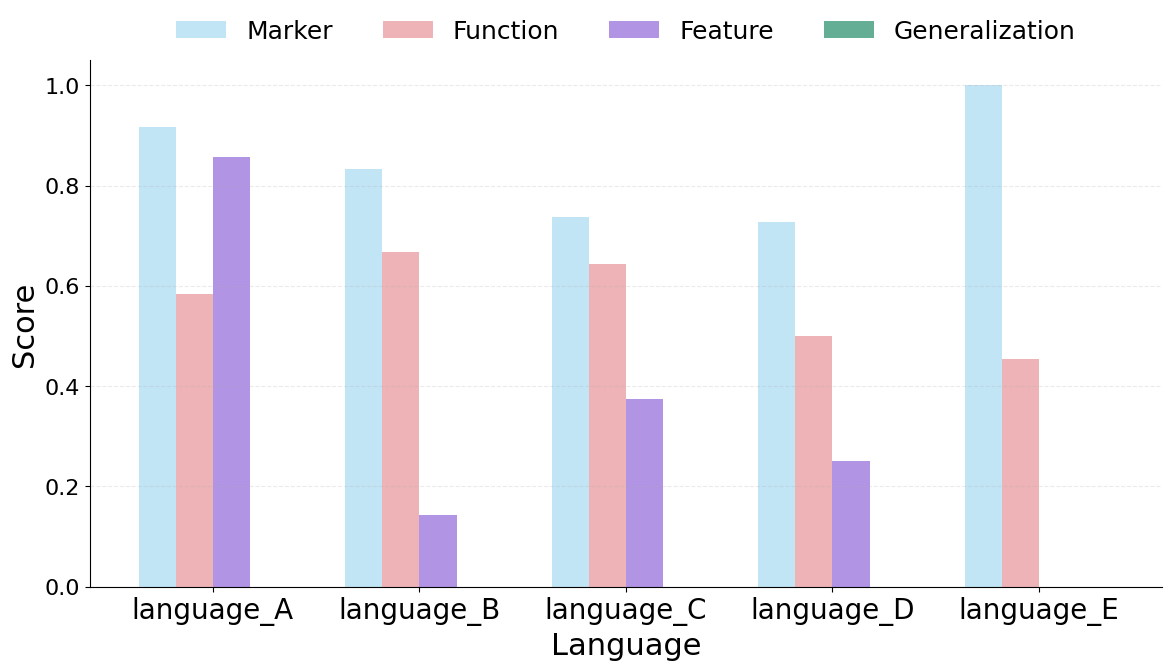

  language_column      true_type predicted_type  type_correct
0      language_A      isolating  agglutinative             0
1      language_B       analytic  agglutinative             0
2      language_C       fusional  agglutinative             0
3      language_D  agglutinative  agglutinative             1
4      language_E  polysynthetic  agglutinative             0

Overall type accuracy: 0.20


In [2]:
# visualization in the without english condition
import matplotlib.pyplot as plt
import numpy as np

# Set global font sizes for the plot
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15
})

# Prepare the data for plotting
df_plot = without_df.copy().sort_values("language_column").reset_index(drop=True)

# Create the bar plot
x = np.arange(len(df_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each score type
colors = {
    "marker": "#C1E5F5",
    "function": "#EDB3B7",
    "feature": "#B194E4",
    "generation": "#65AE96"
}

# Plot each score type as a separate set of bars
ax.bar(
    x - 1.5*width,
    df_plot["marker_score"],
    width,
    label="Marker",
    color=colors["marker"]
)

# Plot function score bars
ax.bar(
    x - 0.5*width,
    df_plot["function_score"],
    width,
    label="Function",
    color=colors["function"]
)

# Plot feature score bars
ax.bar(
    x + 0.5*width,
    df_plot["feature_score"],
    width,
    label="Feature",
    color=colors["feature"]
)

# Plot generation score bars
ax.bar(
    x + 1.5*width,
    df_plot["generation_score"],
    width,
    label="Generalization",
    color=colors["generation"]
)

# Customize the x-axis labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(df_plot["language_column"], fontsize=20)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=22)
ax.set_xlabel("Language", fontsize=22)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    ncol=4,
    bbox_to_anchor=(0.5, 1.12),
    loc="upper center",
    fontsize=18
)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print the type accuracy for each language and the overall accuracy
print(df_plot[["language_column", "true_type", "predicted_type", "type_correct"]])
print(f"\nOverall type accuracy: {df_plot['type_correct'].mean():.2f}")

## 3.2 Scoring the with-English condition

### With-English condition

We analyse the condition in which Qwen 2.5 received the artificial-language forms together with their English translations. Compared to the without-English condition, this setting gives the model access to semantic information. The model can therefore use repeated correspondences between English meanings and artificial-language forms to infer possible grammatical functions.

The full prompting and annotation pipeline for this condition is provided in:

`annotation/With_english_PROMPT_and_TEST.ipynb`

That notebook takes the dataset:

`data/dataset_with_english.csv`

and sends each artificial-language column separately to Qwen 2.5. Each column corresponds to one artificial language. The model is not asked to compare the languages with each other. Instead, for each language separately, it receives examples consisting of an English meaning and the corresponding artificial-language form.

The raw model outputs are saved in:

`raw_outputs/column_annotations_with_english_tagged_raw.json`

These raw outputs are then evaluated using the same predefined ground truth and the same scoring procedure as in the without-English condition.

The scoring procedure computes several metrics:

- marker score;
- function score;
- feature score;
- generation score;
- type classification score;
- overall score.

The final scored table used in this main notebook is:

`data/comparison_with_english.csv`

### Visualization: with-English condition

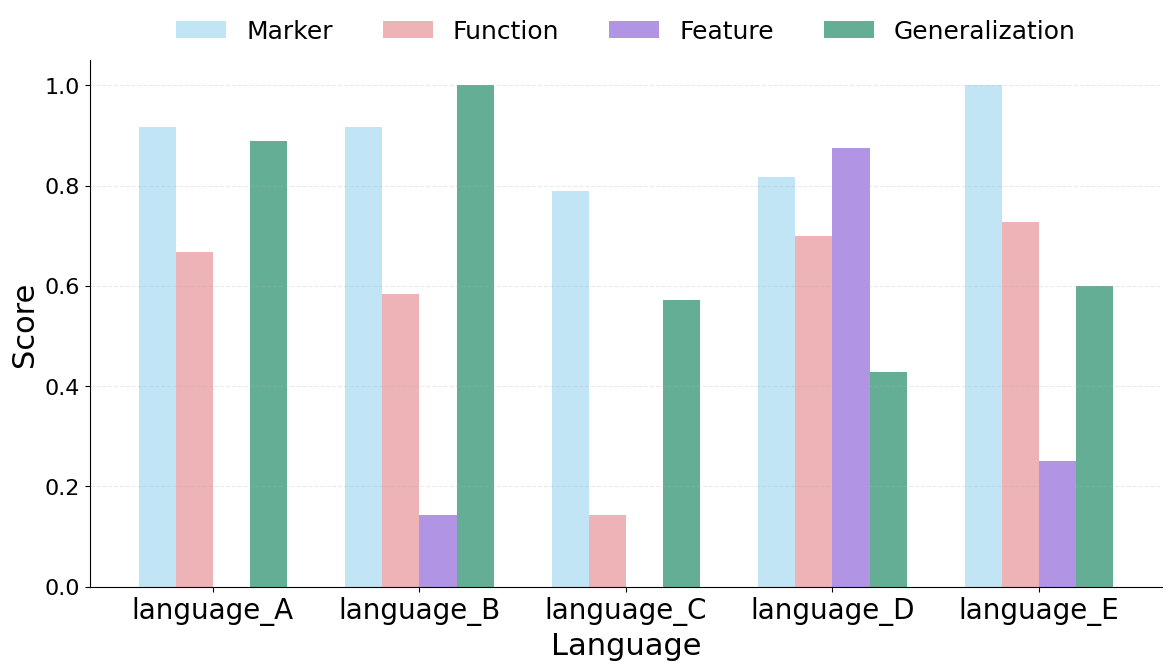

  language_column      true_type predicted_type  type_correct
0      language_A      isolating  agglutinative             0
1      language_B       analytic  agglutinative             0
2      language_C       fusional  agglutinative             0
3      language_D  agglutinative  agglutinative             1
4      language_E  polysynthetic  agglutinative             0

Overall type accuracy: 0.20


In [3]:
# Visualization in the with-english condition
import matplotlib.pyplot as plt
import numpy as np

# Set global font sizes for the plot
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15
})

# Prepare the data for plotting
df_plot = with_df.copy().sort_values("language_column").reset_index(drop=True)

x = np.arange(len(df_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each score type 
colors = {
    "marker": "#C1E5F5",
    "function": "#EDB3B7",
    "feature": "#B194E4",
    "generation": "#65AE96"
}

# Plot each score type as a separate set of bars
ax.bar(
    x - 1.5*width,
    df_plot["marker_score"],
    width,
    label="Marker",
    color=colors["marker"]
)

# Plot function score bars
ax.bar(
    x - 0.5*width,
    df_plot["function_score"],
    width,
    label="Function",
    color=colors["function"]
)

# Plot feature score bars
ax.bar(
    x + 0.5*width,
    df_plot["feature_score"],
    width,
    label="Feature",
    color=colors["feature"]
)

# Plot generation score bars
ax.bar(
    x + 1.5*width,
    df_plot["generation_score"],
    width,
    label="Generalization",
    color=colors["generation"]
)

# Customize the x-axis labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(df_plot["language_column"], fontsize=20)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=22)
ax.set_xlabel("Language", fontsize=22)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    ncol=4,
    bbox_to_anchor=(0.5, 1.12),
    loc="upper center",
    fontsize=18
)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print the type accuracy for each language and the overall accuracy
print(df_plot[["language_column", "true_type", "predicted_type", "type_correct"]])
print(f"\nOverall type accuracy: {df_plot['type_correct'].mean():.2f}")

## 3.3 Direct comparison between conditions

This cell loads the two scored comparison tables, one for the with-English condition and one for the without-English condition. It then merges them by `language_column`, so that each artificial language is compared with itself across the two conditions.

For each score, the cell computes a difference:

`delta = score_with_english - score_without_english`

A positive delta means that the score was higher in the with-English condition. A negative delta means that the score was higher in the without-English condition.

The cell then computes a global summary by averaging each score across the five artificial languages in each condition. Finally, it saves both the language-level paired comparison and the global summary as CSV files.

In [4]:
import pandas as pd

# define a helper function to find the file in multiple possible locations
def find_file(possible_names):
    import os
    search_dirs = [".", "data", "raw_outputs", "details", "outputs", "results"]
    for folder in search_dirs:
        for name in possible_names:
            path = os.path.join(folder, name)
            if os.path.exists(path):
                return path
    raise FileNotFoundError(
        "Could not find any of these files: " + ", ".join(possible_names)
    )

# Load the datasets
with_df = pd.read_csv(find_file(["comparison_with_english.csv"]))
without_df = pd.read_csv(find_file(["comparison_without_english.csv", "comparison_without_english(2).csv"]))

# Perform paired comparison
merged = with_df.merge(
    without_df,
    on="language_column",
    suffixes=("_with_english", "_without_english")
)

# Calculate the deltas for each metric
for col in ["type_correct", "marker_score", "function_score", "feature_score", "overall_score"]:
    merged[f"delta_{col}"] = (
        merged[f"{col}_with_english"] - merged[f"{col}_without_english"]
    )

print("\n Paired Comparison ")

# Print the paired comparison results with deltas
print(merged[[
    "language_column",
    "type_correct_with_english", "type_correct_without_english", "delta_type_correct",
    "marker_score_with_english", "marker_score_without_english", "delta_marker_score",
    "function_score_with_english", "function_score_without_english", "delta_function_score",
    "feature_score_with_english", "feature_score_without_english", "delta_feature_score",
    "overall_score_with_english", "overall_score_without_english", "delta_overall_score"
]])

# Create a summary table of mean scores for each metric with and without English, and the delta
summary = pd.DataFrame({
    "metric": ["type_correct", "marker_score", "function_score", "feature_score", "overall_score"],
    "mean_with_english": [
        merged["type_correct_with_english"].mean(),
        merged["marker_score_with_english"].mean(),
        merged["function_score_with_english"].mean(),
        merged["feature_score_with_english"].mean(),
        merged["overall_score_with_english"].mean(),
    ],
    "mean_without_english": [
        merged["type_correct_without_english"].mean(),
        merged["marker_score_without_english"].mean(),
        merged["function_score_without_english"].mean(),
        merged["feature_score_without_english"].mean(),
        merged["overall_score_without_english"].mean(),
    ]
})

# Calculate the delta in the summary table
summary["delta"] = summary["mean_with_english"] - summary["mean_without_english"]

print("\n Global Summary ")
print(summary)

# Save the results to CSV files
merged.to_csv("with_vs_without_english_paired_comparison.csv", index=False)
summary.to_csv("with_vs_without_english_summary.csv", index=False)


 Paired Comparison 
  language_column  type_correct_with_english  type_correct_without_english  \
0      language_A                          0                             0   
1      language_B                          0                             0   
2      language_C                          0                             0   
3      language_D                          1                             1   
4      language_E                          0                             0   

   delta_type_correct  marker_score_with_english  \
0                   0                      0.917   
1                   0                      0.917   
2                   0                      0.789   
3                   0                      0.818   
4                   0                      1.000   

   marker_score_without_english  delta_marker_score  \
0                         0.917               0.000   
1                         0.833               0.084   
2                         0.737 

## 3.4 Logistic regression

To test whether English translations affected performance, the detailed scoring outputs are converted into item-level binary observations. Each marker, function or feature is coded as a hit (`1`) or a miss (`0`).

The model is:

```text
hit ~ condition + C(language)
```

where `condition = 1` corresponds to the with-English condition and `condition = 0` corresponds to the without-English condition. Language is included as a control because some artificial languages are harder than others.

In [5]:
import pandas as pd
import json
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# helper for reproducibility
def find_file(possible_names):
    import os
    search_dirs = [".", "data", "raw_outputs", "details", "outputs", "results"]
    for folder in search_dirs:
        for name in possible_names:
            path = os.path.join(folder, name)
            if os.path.exists(path):
                return path
    raise FileNotFoundError(
        "Could not find any of these files: " + ", ".join(possible_names)
    )

# Load the datasets
with open(find_file(["comparison_without_english_details.json", "comparison_without_english_details(2).json"]), "r", encoding="utf-8") as f:
    no_eng = json.load(f)

# Load the English condition details
with open(find_file(["comparison_with_english_details.json"]), "r", encoding="utf-8") as f:
    eng = json.load(f)

rows = []

# This function adds rows to the `rows` list for a given details dictionary and condition label.
def add_rows(details_dict, condition_label):
    condition = 1 if condition_label == "with_english" else 0

    for language, details in details_dict.items():

        for marker, d in details["function_details"].items():
            rows.append({
                "language": language,
                "condition": condition,
                "condition_label": condition_label,
                "outcome_type": "function",
                "item": marker,
                "hit": d["function_hit"]
            })

        for feat, d in details["feature_details"].items():
            rows.append({
                "language": language,
                "condition": condition,
                "condition_label": condition_label,
                "outcome_type": "feature",
                "item": feat,
                "hit": d["matched"]
            })

        for cat, d in details["marker_details"].items():
            rows.append({
                "language": language,
                "condition": condition,
                "condition_label": condition_label,
                "outcome_type": "marker",
                "item": cat,
                "hit": d["category_hit"]
            })

add_rows(no_eng, "without_english")
add_rows(eng, "with_english")

# Convert the list of rows into a DataFrame for analysis
long_df = pd.DataFrame(rows)

results = {}
plot_rows = []

# Fit a logistic regression model for each outcome type and store the results
for outcome in ["marker", "function", "feature"]:
    df_sub = long_df[long_df["outcome_type"] == outcome].copy()

# Fit a logistic regression model with 'hit' as the dependent variable and 'condition' and 'language' as independent variables
    model = smf.glm(
        formula="hit ~ condition + C(language)",
        data=df_sub,
        family=sm.families.Binomial()
    ).fit()

    results[outcome] = model

# Extract the coefficient, confidence intervals, and p-value for the 'condition' variable
    coef = model.params["condition"]
    ci_low, ci_high = model.conf_int().loc["condition"]
    pval = model.pvalues["condition"]

# Store the results for plotting
    plot_rows.append({
        "outcome": outcome.capitalize(),
        "coef": coef,
        "low": ci_low,
        "high": ci_high,
        "pval": pval
    })

# Print the model summary
    print("\n" + "="*60)
    print(outcome.upper())
    print(model.summary())




MARKER
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    hit   No. Observations:                   94
Model:                            GLM   Df Residuals:                       88
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28.942
Date:                Sun, 31 May 2026   Deviance:                       57.884
Time:                        19:50:42   Pearson chi2:                     73.6
No. Iterations:                    21   Pseudo R-squ. (CS):             0.1007
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept     

# 4. Conclusion and discussion

## 4.1 Main conclusion

The results suggest a nuanced answer. Qwen 2.5 can infer some aspects of morphological structure, especially recurring markers. Across both conditions, the model often detects repeated forms and sometimes uses them to generate plausible outputs. This means that it is relatively strong at local pattern detection.

However, detecting repeated forms is not the same thing as understanding the grammatical organization of a language. The model is less reliable when it has to infer broader typological structure, such as whether a language is isolating, analytic, fusional, agglutinative or polysynthetic. This distinction is central to the project: Qwen can often identify surface regularities, but this does not necessarily mean that it has recovered the deeper morphological system.

The comparison between the with-English and without-English conditions is also important. English translations can provide semantic cues, and in some individual cases they seem to help the model connect forms to meanings. However, the logistic regressions did not show a statistically significant effect of the English condition on marker detection, function identification or feature identification. This means that English translations did not produce a robust overall improvement in this revised experiment. 
One striking result concerns the generation score. In the without-English condition, the generation score is zero for all five languages. This does not mean that Qwen produced no forms. The raw outputs show that the model did generate artificial-language sequences. However, these generations were not validated by the scoring procedure because, without English translations, the model often did not associate the generated forms with the expected target meanings.

In other words, the problem is not only form production. Qwen can imitate visible sequences from the artificial languages. The difficulty is controlled generalization: generating a form that corresponds to a specific grammatical meaning such as future, past, motion toward a place, or motion into a place.

This contrasts with the with-English condition, where generation scores become positive for all languages. English translations provide explicit semantic targets, making it easier for the model to reuse visible patterns in a way that matches the expected meanings. Therefore, English seems especially useful for the generation task, even if it does not produce a statistically significant improvement for marker, function, or feature identification.

Overall, the project suggests that LLMs can perform part of the work of a linguist, especially pattern recognition and local form-meaning mapping. However, their reasoning remains fragile when the task requires abstract typological inference, precise morphological analysis and uncertainty management.

## 4.2 Answer to the hypotheses

**H1. The model will successfully identify recurring morphological markers.**
This hypothesis is supported. Marker scores are generally high in both conditions. This suggests that Qwen 2.5 is relatively good at detecting repeated forms in the artificial-language data.

**H2. English translations will improve the inference of grammatical functions.**
This hypothesis is not clearly supported. Some descriptive patterns suggest that English translations may help in specific cases, but the logistic regression did not show a significant effect of the English condition on function identification. Therefore, English translations did not reliably improve function inference in this revised version of the experiment.

**H3. Typological classification and feature identification will be more difficult than local marker detection.**
This hypothesis is supported. The model performs better on marker detection than on broader typological features. This suggests that identifying repeated forms is easier for the model than inferring the abstract organization of a morphological system.

**H4. Morphologically complex systems, especially fusional and polysynthetic languages, will be harder to analyze than isolating and analytic systems.**
This hypothesis is partially supported. Language C, the fusional system, remains difficult because person and tense are compressed into prefixes. However, performance is not uniformly worse for all complex systems. This suggests that morphological complexity matters, but that visibility and repetition of markers also influence the model’s performance.

**H5. English translations will improve semantic interpretation and function identification more than broader typological reasoning.**
This hypothesis receives only weak support. The expectation was that English translations would help the model map forms to meanings. However, the regression results do not show a significant effect of English on function identification. English may help in some local cases, but it does not systematically improve either function inference or typological reasoning.

The strongest result is therefore that Qwen 2.5 is better at detecting recurring markers than at inferring deeper morphological structure. The weaker result concerns English translations: in this revised experiment, English does not produce a robust improvement.

## 4.3 Comparison with the previous version of the project

These results are especially interesting when compared with the earlier version of the project.

In the first version, English translations seemed to help more clearly with function identification. However, the artificial languages were also less carefully controlled. Some forms were closer to patterns found in real languages, and some markers may have made the intended grammatical system easier to guess.

In the revised version, I redesigned the artificial languages to make the typological contrasts clearer and more controlled. The new languages distinguish more explicitly between free particles, auxiliary-like function words, fused prefixes, suffix chains and polysynthetic-style complex predicates. This makes the task more demanding: the model must infer not only that forms repeat, but also how grammatical information is structurally encoded.

After this redesign, the advantage of English translations becomes weaker and less systematic. This suggests that part of the effect observed in the earlier version may have depended on the transparency of the language design rather than on genuine morphological reasoning.

This comparison strengthens the interpretation of the project. Qwen 2.5 can detect patterns and sometimes map forms to meanings, but it remains fragile when the task requires abstract typological reasoning. The revised languages provide a more demanding test of whether the model can truly “do the work of a linguist.”

## 4.4 Limitations

There are several limitations to this project.

First, the experiment uses artificial languages. This is useful because it allows full control over the ground truth, but artificial systems are still simpler than natural languages. Real languages contain irregularity, ambiguity, variation, historical residue and noise.

Second, only five artificial languages were tested. This makes the project manageable, but it limits statistical power. The logistic regression results should therefore be interpreted cautiously. A larger experiment with more artificial languages or more examples per type would make the statistical analysis stronger.

Third, the scoring procedure is rule-based. This makes the evaluation transparent and reproducible, but it also means that the results depend on predefined markers, functions and keywords. Some correct answers may be missed if the model uses unexpected wording.

Fourth, the project tests only one model pipeline, Qwen 2.5. Future work should compare several models to see whether these results are specific to Qwen or reflect a broader limitation of current LLMs.

Finally, the project focuses on morphology. A natural extension would be to test whether models can infer syntactic structure, argument roles, agreement systems or hierarchical dependencies in artificial languages.

## 4.5 Future improvements

Several improvements could strengthen the project.

A first improvement would be to create more artificial languages for each typological category. Instead of having one isolating language, one analytic language, one fusional language, one agglutinative language and one polysynthetic language, future work could create several variants of each type. This would make it possible to test whether the results generalize across systems.

A second improvement would be to compare multiple LLMs. For example, the same experiment could be run with Qwen, Llama, Gemma and GPT-style models. This would help determine whether the observed difficulties are specific to one model or shared across model families.

A third improvement would be to include human evaluation. Rule-based scoring is useful, but human linguistic judgment could help evaluate whether the model’s explanations are plausible even when they do not use the exact expected keywords.

A fourth improvement would be to test additional linguistic domains. Morphology is only one part of grammatical structure. Future experiments could test syntax, word order, agreement, case marking, argument structure or semantic roles.

## 4.6 Reproducibility note

The language construction notebook is provided in:

`language_generation/Languages_Construction.ipynb`

The Qwen annotation notebooks are provided in:

`annotation/With_english_PROMPT_and_TEST.ipynb`

and:

`annotation/Without_english_PROMPT_and_TEST.ipynb`

The scored comparison files used in this main notebook are stored in:

`data/comparison_with_english.csv`

`data/comparison_without_english.csv`

`data/with_vs_without_english_summary.csv`

`data/with_vs_without_english_paired_comparison.csv`

# References

Asgari, E., El Kheir, Y., & Javaheri, M. A. S. (2025). *MorphBPE: A morpho-aware tokenizer bridging linguistic complexity for efficient LLM training across morphologies*. arXiv.

Chomsky, N. (1965). *Aspects of the Theory of Syntax*. MIT Press.

Lu, Y., Zhu, W., Li, L., Qiao, Y., & Yuan, F. (2024). *LLaMAX: Scaling linguistic horizons of LLM by enhancing translation capabilities beyond 100 languages*. Findings of EMNLP 2024.

Piantadosi, S. T. (2024). Modern language models refute Chomsky's approach to language. In E. Gibson & M. Poliak (Eds.), *From fieldwork to linguistic theory: A tribute to Dan Everett*.

Sachdeva, N., Coleman, B., Kang, W.-C., Ni, J., Hong, L., Chi, E. H., Caverlee, J., McAuley, J., & Cheng, D. Z. (2024). *How to train data-efficient LLMs*. arXiv.

Weissweiler, L., Köksal, A., & Schütze, H. (2024). *Hybrid human-LLM corpus construction and LLM evaluation for rare linguistic phenomena*. arXiv.